# Shoulder Flexion/Extension — Recording Type Comparison
Compares angular results (ROM, Maximum, Minimum) across four recording types:
**Continuous Unilateral · Continuous Bilateral · Individual Unilateral · Individual Bilateral**

Three separate figures are generated (one per metric), each showing Left and Right sides
with 4 raincloud plots per side.

## 1. Imports

## 2. C3D & segmentation functions (self-contained, no project imports needed)\n\nRequires: `pip install ezc3d`

In [1]:
# ── C3D reading ───────────────────────────────────────────────────────────

def _extract_events(c: object, frame_rate: int) -> list[dict]:
    events: list[dict] = []
    try:
        params = c["parameters"]
        if "EVENT" not in params:
            return events
        ev = params["EVENT"]
        raw_times = ev.get("TIMES", {}).get("value", [])
        labels: list[str] = ev.get("LABELS", {}).get("value", [])
        if hasattr(raw_times, "ndim"):
            times_arr = np.asarray(raw_times, dtype=float)
            if times_arr.ndim == 2 and times_arr.shape[0] >= 2:
                time_values = times_arr[1, :]
            else:
                time_values = times_arr.ravel()
        elif raw_times and isinstance(raw_times[0], (list, tuple)):
            time_values = [float(t) for t in raw_times[1]]
        else:
            time_values = [float(t) for t in raw_times]
        for i, t in enumerate(time_values):
            frame = int(round(float(t) * frame_rate))
            name = labels[i] if i < len(labels) else f"Event_{i}"
            events.append({"name": name.strip(), "frame": frame, "time": float(t)})
    except Exception:
        pass
    return events


def read_c3d(filepath: str) -> dict:
    """Read a Vicon Nexus C3D file. Requires: pip install ezc3d"""
    try:
        import ezc3d as _ezc3d
    except ImportError as exc:
        raise ImportError("ezc3d is required. Install with: pip install ezc3d") from exc

    filepath = os.path.normpath(os.path.abspath(filepath))
    c = _ezc3d.c3d(filepath)

    raw_labels: list[str] = c["parameters"]["POINT"]["LABELS"]["value"]
    point_data: np.ndarray = c["data"]["points"]   # (4, n_labels, n_frames)
    n_labels = min(len(raw_labels), point_data.shape[1])
    n_frames = point_data.shape[2]

    try:
        rate_val = c["parameters"]["POINT"]["RATE"]["value"]
        frame_rate = int(float(rate_val[0]) if hasattr(rate_val, "__len__") else float(rate_val))
    except (KeyError, IndexError, TypeError, ValueError):
        frame_rate = int(c["header"]["frame_rate"])

    # Strip subject prefix (e.g. "Fernando_grab3:LThoraxAngles" → "LThoraxAngles")
    clean_labels = [
        lbl.split(":")[-1].strip() if ":" in lbl else lbl.strip()
        for lbl in raw_labels[:n_labels]
    ]
    model_outputs: dict[str, np.ndarray] = {
        lbl: point_data[:3, i, :].copy()
        for i, lbl in enumerate(clean_labels)
    }

    return {
        "frame_rate":   frame_rate,
        "n_frames":     n_frames,
        "point_labels": clean_labels,
        "model_outputs": model_outputs,
        "events":       _extract_events(c, frame_rate),
    }


# ── Statistics ────────────────────────────────────────────────────────────

def compute_extended_stats_array(
    angle_data: np.ndarray,
    segments: list[tuple[int, int]],
) -> dict:
    """ROM, peak, and valley per repetition segment."""
    roms, peaks, valleys = [], [], []
    for s, e in segments:
        chunk = angle_data[s: e + 1]
        valid = chunk[~np.isnan(chunk)]
        if valid.size == 0:
            roms.append(float("nan")); peaks.append(float("nan")); valleys.append(float("nan"))
        else:
            roms.append(float(np.nanmax(chunk) - np.nanmin(chunk)))
            peaks.append(float(np.nanmax(chunk)))
            valleys.append(float(np.nanmin(chunk)))

    def _agg(values):
        v = np.array([x for x in values if not np.isnan(x)])
        return {
            "values": values,
            "mean": float(np.mean(v))        if v.size > 0 else float("nan"),
            "sd":   float(np.std(v, ddof=1)) if v.size > 1 else 0.0,
            "min":  float(np.min(v))          if v.size > 0 else float("nan"),
            "max":  float(np.max(v))          if v.size > 0 else float("nan"),
        }

    return {"rom": _agg(roms), "peak": _agg(peaks), "valley": _agg(valleys)}


# ── Segmentation ──────────────────────────────────────────────────────────

def detect_peaks_valleys(
    angle_data: np.ndarray,
    min_prominence: float,
    min_distance: int,
) -> tuple[np.ndarray, np.ndarray]:
    clean = np.where(np.isnan(angle_data), np.nanmean(angle_data), angle_data)
    peaks,   _ = find_peaks( clean, prominence=min_prominence, distance=min_distance)
    valleys, _ = find_peaks(-clean, prominence=min_prominence, distance=min_distance)
    return peaks, valleys


def auto_segment(
    angle_data: np.ndarray,
    min_prominence: float,
    min_distance: int,
    cycle_from: str = "halfcycle",
) -> tuple[list[tuple[int, int]], np.ndarray, np.ndarray]:
    peaks, valleys = detect_peaks_valleys(angle_data, min_prominence, min_distance)

    if cycle_from in ("valley", "peak"):
        anchors = valleys if cycle_from == "valley" else peaks
        segments = [(int(anchors[i]), int(anchors[i + 1])) for i in range(len(anchors) - 1)]
    else:
        combined = sorted(
            [(int(f), "peak") for f in peaks] + [(int(f), "valley") for f in valleys],
            key=lambda x: x[0],
        )
        if cycle_from == "halfcycle_peak_to_valley":
            segments = [
                (combined[i][0], combined[i + 1][0])
                for i in range(len(combined) - 1)
                if combined[i][1] == "peak" and combined[i + 1][1] == "valley"
            ]
        elif cycle_from == "halfcycle_valley_to_peak":
            segments = [
                (combined[i][0], combined[i + 1][0])
                for i in range(len(combined) - 1)
                if combined[i][1] == "valley" and combined[i + 1][1] == "peak"
            ]
        else:
            segments = [(combined[i][0], combined[i + 1][0]) for i in range(len(combined) - 1)]

    return segments, peaks, valleys

In [2]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

## 3. Configuration\n**Edit only this cell** to point to your recording files.

In [3]:
# ── Base directory (all recordings in the same folder) ────────────────────
BASE_DIR = r"C:\Projects\data_organized\grab 3_c3d"

# ── Continuous recordings — filenames are fixed ────────────────────────────
C3D_CONTINUOUS_LEFT      = BASE_DIR + r"\Shoulder_Flex_Ext_Left_Cont01.c3d"
C3D_CONTINUOUS_RIGHT     = BASE_DIR + r"\Shoulder_Flex_Ext_Right_Cont01.c3d"
C3D_CONTINUOUS_BILATERAL = BASE_DIR + r"\Shoulder_Flex_Ext_Bi_Cont01.c3d"

# ── Individual (single-rep) recordings ────────────────────────────────────
# Pattern: {DIR}\Shoulder_Flex_Ext_Left_{N}.c3d  (N = START … END, inclusive)

INDIVIDUAL_LEFT_DIR    = BASE_DIR   # Shoulder_Flex_Ext_Left_1.c3d, _2.c3d, …
INDIVIDUAL_LEFT_START  = 1
INDIVIDUAL_LEFT_END    = 8

INDIVIDUAL_RIGHT_DIR   = BASE_DIR   # Shoulder_Flex_Ext_Right_1.c3d, _2.c3d, …
INDIVIDUAL_RIGHT_START = 1
INDIVIDUAL_RIGHT_END   = 8

INDIVIDUAL_BI_DIR      = BASE_DIR   # Shoulder_Flex_Ext_Bi_1.c3d, _2.c3d, …
INDIVIDUAL_BI_START    = 1
INDIVIDUAL_BI_END      = 6

# ── Output ─────────────────────────────────────────────────────────────────
OUTPUT_DIR = None   # set to r"C:\path\to\output" to save PNGs; None = show only
DPI = 150

## 4. Helper functions

In [4]:
def build_file_list(directory: str, prefix: str, start: int, end: int) -> list[str]:
    """
    Returns a list of C3D paths for files named {prefix}{number:02d}.c3d.
    Tries zero-padded (2-digit) first; falls back to no padding.
    Warns and skips missing files.
    """
    base = Path(directory)
    files: list[str] = []
    for i in range(start, end + 1):
        p_padded   = base / f"{prefix}{i:02d}.c3d"
        p_unpadded = base / f"{prefix}{i}.c3d"
        if p_padded.exists():
            files.append(str(p_padded))
        elif p_unpadded.exists():
            files.append(str(p_unpadded))
        else:
            print(f"  WARNING: file not found — {p_padded} (also tried {p_unpadded.name})")
    return files

## 5. C3D loading and segmentation

In [5]:
# ── Fixed movement settings ────────────────────────────────────────────────
# Label: Left/RightHumerothoracic_ZXY_Op1  |  Axis X (index 0)
# Maximum = Flexion, Minimum = Extension
VARIABLE_NAME       = "Humerothoracic_ZXY_Op1"
COMPONENT_INDEX     = 0        # X axis = flexion/extension
PROMINENCE          = 15.0
MIN_DISTANCE        = 60
HALFCYCLE_DIRECTION = "peak_to_valley"


def _label_for_side(variable: str, side: str) -> str:
    if side == "—":
        return variable
    return side + variable   # e.g. "Left" + "Humerothoracic_ZXY_Op1"


def load_and_segment(
    c3d_files: list[str],
    variable: str,
    component: int,
    side: str,
    prominence: float,
    min_distance: int,
    direction: str,
) -> dict:
    """
    Reads all C3D files, extracts the angular curve for one side, segments it.
    Returns {"extended": {"rom": {...}, "peak": {...}, "valley": {...}}, ...}
    Each metric dict has keys: values, mean, sd, min, max.
    """
    all_roms:    list[float] = []
    all_peaks:   list[float] = []
    all_valleys: list[float] = []
    last_angle:  np.ndarray | None = None
    last_fr:     int = 100

    for path in c3d_files:
        print(f"  Reading: {path}")
        c3d = read_c3d(path)
        fr  = c3d["frame_rate"]
        last_fr = fr

        label = _label_for_side(variable, side)
        mo = c3d["model_outputs"]

        if label not in mo:
            available = [k for k in mo if variable in k or side in k]
            raise KeyError(
                f"Label '{label}' not found in {Path(path).name}.\n"
                f"Partially matching labels: {available}\n"
                f"All labels: {list(mo.keys())}"
            )

        angle = mo[label][component, :].astype(float)
        last_angle = angle

        cycle_from = f"halfcycle_{direction}"
        segments, _, _ = auto_segment(angle, prominence, min_distance,
                                      cycle_from=cycle_from)

        if not segments:
            print(f"    WARNING: no segments detected in {Path(path).name}")
            continue

        stats = compute_extended_stats_array(angle, segments)
        all_roms    += stats["rom"]["values"]
        all_peaks   += stats["peak"]["values"]
        all_valleys += stats["valley"]["values"]

    def _agg(values: list[float]) -> dict:
        valid = np.array([v for v in values if not np.isnan(v)])
        return {
            "values": values,
            "mean": float(np.mean(valid))        if valid.size > 0 else float("nan"),
            "sd":   float(np.std(valid, ddof=1)) if valid.size > 1 else 0.0,
            "min":  float(np.min(valid))          if valid.size > 0 else float("nan"),
            "max":  float(np.max(valid))          if valid.size > 0 else float("nan"),
        }

    return {
        "extended": {
            "rom":    _agg(all_roms),
            "peak":   _agg(all_peaks),
            "valley": _agg(all_valleys),
        },
        "angle_data": last_angle,
        "frame_rate": last_fr,
    }

## 6. Load all recordings

In [6]:
RECORDING_TYPES = [
    "Continuous Unilateral",
    "Continuous Bilateral",
    "Individual Unilateral",
    "Individual Bilateral",
]
SIDES = ["Left", "Right"]

# ── Build individual file lists using the actual filename prefixes ──────────
files_individual_left = build_file_list(
    INDIVIDUAL_LEFT_DIR, "Shoulder_Flex_Ext_Left_",
    INDIVIDUAL_LEFT_START, INDIVIDUAL_LEFT_END,
)
files_individual_right = build_file_list(
    INDIVIDUAL_RIGHT_DIR, "Shoulder_Flex_Ext_Right_",
    INDIVIDUAL_RIGHT_START, INDIVIDUAL_RIGHT_END,
)
files_individual_bi = build_file_list(
    INDIVIDUAL_BI_DIR, "Shoulder_Flex_Ext_Bi_",
    INDIVIDUAL_BI_START, INDIVIDUAL_BI_END,
)

# ── Map (side, recording_type) → C3D file list ────────────────────────────
_source_files: dict[tuple[str, str], list[str]] = {
    ("Left",  "Continuous Unilateral"):  [C3D_CONTINUOUS_LEFT],
    ("Right", "Continuous Unilateral"):  [C3D_CONTINUOUS_RIGHT],
    ("Left",  "Continuous Bilateral"):   [C3D_CONTINUOUS_BILATERAL],
    ("Right", "Continuous Bilateral"):   [C3D_CONTINUOUS_BILATERAL],
    ("Left",  "Individual Unilateral"):  files_individual_left,
    ("Right", "Individual Unilateral"):  files_individual_right,
    ("Left",  "Individual Bilateral"):   files_individual_bi,
    ("Right", "Individual Bilateral"):   files_individual_bi,
}

# ── Load ───────────────────────────────────────────────────────────────────
def _empty_result() -> dict:
    empty = {"values": [], "mean": float("nan"), "sd": 0.0,
             "min": float("nan"), "max": float("nan")}
    return {"extended": {"rom": {**empty}, "peak": {**empty}, "valley": {**empty}},
            "angle_data": None, "frame_rate": 100}

recording_data: dict[tuple[str, str], dict] = {}

for side in SIDES:
    for rec_type in RECORDING_TYPES:
        key   = (side, rec_type)
        files = _source_files[key]
        if not files:
            print(f"\nSkipping {side} / {rec_type}: no files found.")
            recording_data[key] = _empty_result()
            continue
        print(f"\nLoading: {side} / {rec_type} ({len(files)} file(s))")
        try:
            recording_data[key] = load_and_segment(
                c3d_files    = files,
                variable     = VARIABLE_NAME,
                component    = COMPONENT_INDEX,
                side         = side,
                prominence   = PROMINENCE,
                min_distance = MIN_DISTANCE,
                direction    = HALFCYCLE_DIRECTION,
            )
        except Exception as e:
            print(f"  ERROR: {e}")
            recording_data[key] = _empty_result()

# ── Summary table ──────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print(f"{'Side':<8} {'Recording Type':<26} {'Metric':<8} {'n':>4} {'Mean':>8} {'SD':>8}")
print("=" * 72)
for side in SIDES:
    for rec_type in RECORDING_TYPES:
        result = recording_data[(side, rec_type)]
        for metric in ("rom", "peak", "valley"):
            m = result["extended"][metric]
            valid = [v for v in m["values"] if v is not None and not np.isnan(float(v))]
            n        = len(valid)
            mean_str = f"{m['mean']:.1f}°" if not np.isnan(m["mean"]) else "—"
            sd_str   = f"{m['sd']:.1f}°"   if n > 1 else "—"
            print(f"{side:<8} {rec_type:<26} {metric:<8} {n:>4} {mean_str:>8} {sd_str:>8}")


Loading: Left / Continuous Unilateral (1 file(s))
  Reading: C:\Projects\data_organized\grab 3_c3d\Shoulder_Flex_Ext_Left_Cont01.c3d

Loading: Left / Continuous Bilateral (1 file(s))
  Reading: C:\Projects\data_organized\grab 3_c3d\Shoulder_Flex_Ext_Bi_Cont01.c3d

Loading: Left / Individual Unilateral (8 file(s))
  Reading: C:\Projects\data_organized\grab 3_c3d\Shoulder_Flex_Ext_Left_1.c3d
  Reading: C:\Projects\data_organized\grab 3_c3d\Shoulder_Flex_Ext_Left_2.c3d
  Reading: C:\Projects\data_organized\grab 3_c3d\Shoulder_Flex_Ext_Left_3.c3d
  Reading: C:\Projects\data_organized\grab 3_c3d\Shoulder_Flex_Ext_Left_4.c3d
  Reading: C:\Projects\data_organized\grab 3_c3d\Shoulder_Flex_Ext_Left_5.c3d
  Reading: C:\Projects\data_organized\grab 3_c3d\Shoulder_Flex_Ext_Left_6.c3d
  Reading: C:\Projects\data_organized\grab 3_c3d\Shoulder_Flex_Ext_Left_7.c3d
  Reading: C:\Projects\data_organized\grab 3_c3d\Shoulder_Flex_Ext_Left_8.c3d

Loading: Left / Individual Bilateral (6 file(s))
  Reading:

## 7. Color palette

In [7]:
# (fill_color, dark_outline_color) per side × recording type
COLORS: dict[str, dict[str, tuple[str, str]]] = {
    "Left": {
        "Continuous Unilateral":  ("#922B21", "#641E16"),
        "Continuous Bilateral":   ("#C0392B", "#922B21"),
        "Individual Unilateral":  ("#E74C3C", "#C0392B"),
        "Individual Bilateral":   ("#F1948A", "#E74C3C"),
    },
    "Right": {
        "Continuous Unilateral":  ("#145A32", "#0B3B21"),
        "Continuous Bilateral":   ("#1E8449", "#145A32"),
        "Individual Unilateral":  ("#2ECC71", "#1E8449"),
        "Individual Bilateral":   ("#82E0AA", "#2ECC71"),
    },
}

SIDE_LABEL_COLORS = {"Left": "#641E16", "Right": "#0B3B21"}

## 8. Raincloud drawing function

In [8]:
_V_AMP  = 0.25
_BW     = 0.025
_SC_OFF = 0.08
_SC_JIT = 0.025


def _draw_raincloud(
    ax: plt.Axes,
    vals: np.ndarray,
    x_c: float,
    color: str,
    color_dark: str,
    rng: np.random.Generator,
) -> None:
    """Violin (left) + boxplot (centre) + jittered scatter (right)."""
    vals = np.asarray(vals, dtype=float)
    vals = vals[~np.isnan(vals)]
    if vals.size == 0:
        return

    # 1. Half-violin to the left of x_c
    if vals.size >= 2:
        kde    = gaussian_kde(vals, bw_method="scott")
        spread = max(float(vals.std()) * 0.5, 0.5)
        y_grid = np.linspace(vals.min() - spread, vals.max() + spread, 300)
        dens   = kde(y_grid)
        peak_d = dens.max()
        if peak_d > 0:
            kde_x = x_c - (dens / peak_d) * _V_AMP
            ax.fill_betweenx(y_grid, kde_x, x_c,
                             color=color, alpha=0.35, zorder=2)
            ax.plot(kde_x, y_grid, color=color, alpha=0.70,
                    linewidth=0.9, zorder=3)

    # 2. Vertical boxplot
    q1, q2, q3 = np.percentile(vals, [25, 50, 75])
    iqr      = q3 - q1
    fence_lo = q1 - 1.5 * iqr
    fence_hi = q3 + 1.5 * iqr
    w_lo = vals[vals >= fence_lo].min() if np.any(vals >= fence_lo) else q1
    w_hi = vals[vals <= fence_hi].max() if np.any(vals <= fence_hi) else q3

    ax.plot([x_c, x_c], [w_lo, q1], color=color, lw=1.2, zorder=4)
    ax.plot([x_c, x_c], [q3, w_hi], color=color, lw=1.2, zorder=4)
    for wy in (w_lo, w_hi):
        ax.plot([x_c - _BW, x_c + _BW], [wy, wy], color=color, lw=1.2, zorder=4)
    ax.add_patch(Rectangle(
        (x_c - _BW, q1), 2 * _BW, q3 - q1,
        facecolor="white", edgecolor=color, linewidth=1.5, zorder=5,
    ))
    ax.plot([x_c - _BW, x_c + _BW], [q2, q2], color=color, lw=2.0, zorder=6)

    mean_val = float(vals.mean())
    ax.text(x_c, w_hi, f"{mean_val:.1f}\u00b0",
            ha="center", va="bottom", fontsize=7.5,
            fontweight="bold", color=color_dark, zorder=7)

    outliers = vals[(vals < w_lo) | (vals > w_hi)]
    if outliers.size:
        ax.scatter(np.full(outliers.size, x_c), outliers,
                   color=color, s=18, marker="D", alpha=0.85, zorder=7)

    # 3. Jittered scatter to the right
    jitter = rng.uniform(-_SC_JIT, _SC_JIT, size=vals.size)
    ax.scatter(x_c + _SC_OFF + jitter, vals,
               color=color, s=25, alpha=0.80, zorder=3,
               edgecolors=color_dark, linewidths=0.4)

## 9. Plot function

In [9]:
# X-axis spacing: 4 raincloud plots per side, evenly spaced within each subplot
_SPACING = 0.55   # distance between adjacent recording types

# Per-subplot x positions: re-centred so the first type starts at x=0
_n = len(RECORDING_TYPES)
_SUBPLOT_X: dict[str, float] = {rt: i * _SPACING for i, rt in enumerate(RECORDING_TYPES)}

# X-axis limits are identical for both Left and Right subplots
_subplot_x_min = -_V_AMP - 0.18
_subplot_x_max = (_n - 1) * _SPACING + _SC_OFF + _SC_JIT + 0.18

# Abbreviated two-line tick labels
_XTICK_LABELS = {
    "Continuous Unilateral":  "Cont.\nUnil.",
    "Continuous Bilateral":   "Cont.\nBil.",
    "Individual Unilateral":  "Indiv.\nUnil.",
    "Individual Bilateral":   "Indiv.\nBil.",
}


def plot_metric(metric_key: str, metric_title: str) -> plt.Figure:
    """
    One figure with 2 subplots (Left | Right).
    Each subplot contains 4 raincloud plots, one per recording type.
    """
    rng = np.random.default_rng(42)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        f"Shoulder Flexion/Extension — {metric_title}",
        fontsize=13, fontweight="bold",
    )
    fig.subplots_adjust(wspace=0.35, top=0.88, bottom=0.22)

    for ax, side in zip(axes, SIDES):
        ax.set_title(side, fontsize=11, fontweight="bold",
                     color=SIDE_LABEL_COLORS[side])

        tick_x: list[float] = []
        tick_labels: list[str] = []

        for rec_type in RECORDING_TYPES:
            raw = (recording_data[(side, rec_type)]["extended"]
                   .get(metric_key, {}).get("values", []))
            vals = np.array(
                [v for v in raw if v is not None and not np.isnan(float(v))],
                dtype=float,
            )
            x_c = _SUBPLOT_X[rec_type]
            color, color_dark = COLORS[side][rec_type]
            _draw_raincloud(ax, vals, x_c, color, color_dark, rng)
            tick_x.append(x_c)
            tick_labels.append(_XTICK_LABELS[rec_type])

        ax.set_xticks(tick_x)
        ax.set_xticklabels(tick_labels, fontsize=8)
        ax.set_xlim(_subplot_x_min, _subplot_x_max)
        ax.tick_params(axis="x", length=0)
        ax.margins(y=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
        ax.set_ylabel("Angle (°)", fontsize=9)

    # Shared legend — one patch per recording type (darkest Left shade)
    legend_handles = [
        mpatches.Patch(facecolor=COLORS["Left"][rt][0], label=rt)
        for rt in RECORDING_TYPES
    ]
    fig.legend(
        handles=legend_handles,
        fontsize=9, ncol=4,
        loc="lower center", bbox_to_anchor=(0.5, -0.02),
        frameon=True, handlelength=1.2, handletextpad=0.5,
        columnspacing=1.2, borderpad=0.5,
    )
    return fig

## 10. Generate the three figures


Generating: Range of Motion (ROM)


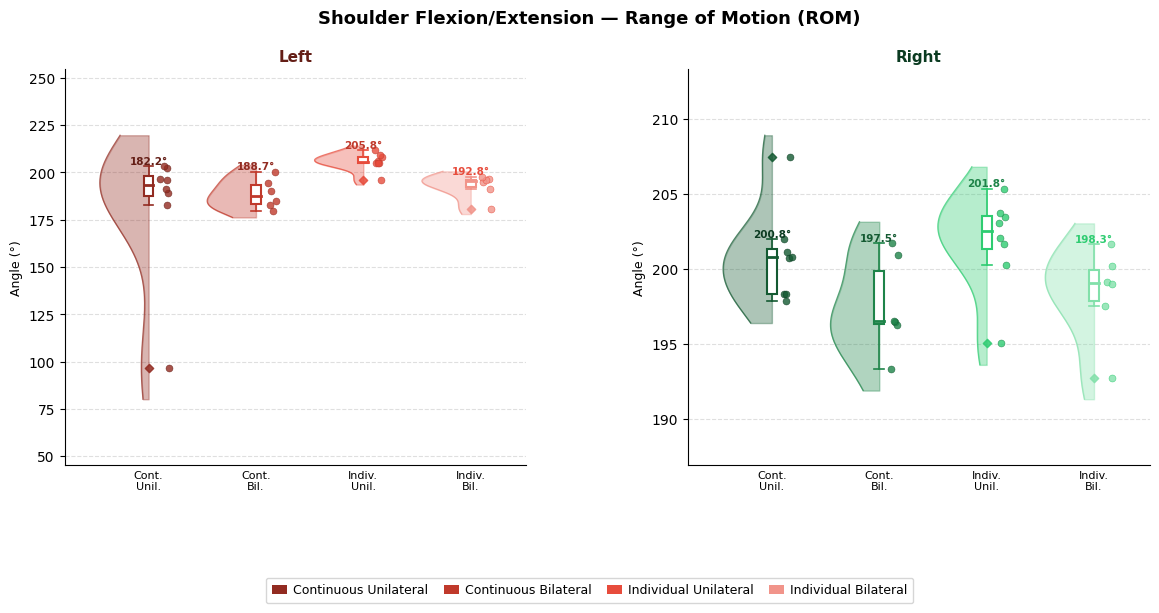


Generating: Maximum Angle


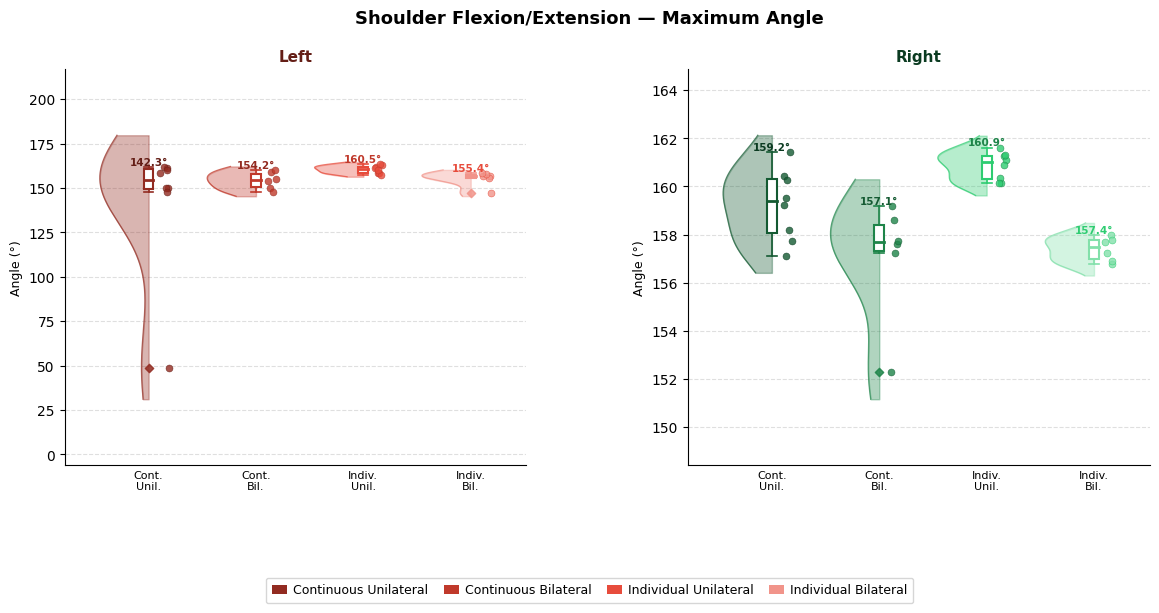


Generating: Minimum Angle


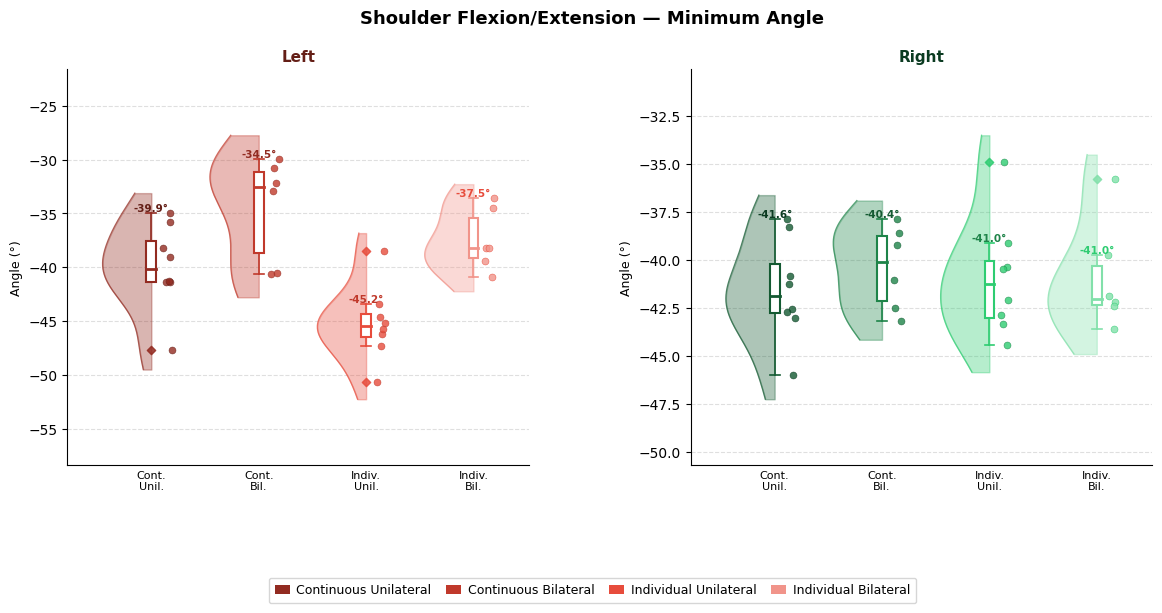

In [10]:
METRICS_TO_PLOT = [
    ("rom",    "Range of Motion (ROM)"),
    ("peak",   "Maximum Angle"),
    ("valley", "Minimum Angle"),
]

if OUTPUT_DIR:
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

for metric_key, metric_title in METRICS_TO_PLOT:
    print(f"\nGenerating: {metric_title}")
    fig = plot_metric(metric_key, metric_title)
    if OUTPUT_DIR:
        fname = Path(OUTPUT_DIR) / f"shoulder_flexext_{metric_key}.png"
        fig.savefig(fname, dpi=DPI, bbox_inches="tight")
        print(f"  Saved: {fname}")
    plt.show()